# Step 3.2.2: 图数据集构建 (Graph Dataset Construction)

## 📋 数据准备说明

**重要**: 本notebook使用Gradient Sports数据集中的Rosters数据作为球员位置信息来源。

### 必需的数据文件

本notebook需要以下数据文件：

1. **Rosters数据** - 每场比赛的球员阵容和位置信息
   - 位置: `E:\JerryWu\Master\SoccerAnalytics\OpenData\TrackingData\Gradient Sports  Enhanced 2022 World Cup Dataset\Rosters\`
   - 文件格式: JSON文件，文件名为比赛ID（如10517.json）
   - 包含信息:
     - 球员ID (player.id)
     - 球员姓名 (player.nickname)
     - 详细位置 (positionGroupType): GK, LCB, RCB, LWB, RWB, MCB, LB, RB, DM, CM, AM, LW, RW, CF等
     - 球衣号码 (shirtNumber)
     - 是否首发 (started)
     - 所属球队 (team.id, team.name)

2. **博彩赔率数据** - 反映赛前实力对比
   - 位置: `E:\JerryWu\Master\SoccerAnalytics\OpenData\2022 WC prediction\Odds\`
   - 文件: `odds_2022WC.xlsx` (整合的世界杯赔率数据)
   - 包含: 主胜赔率、平局赔率、客胜赔率

---

## 目标

构建PyTorch Geometric数据集，整合以下特征：

1. **节点特征** (Node Features):
   - 位置坐标 (x, y)
   - 速度分量 (vx, vy)
   - 到球距离 (distance_to_ball)
   - Rosters位置编码 (roster_position) - 26维
   - Shape Graph位置 (vertical_level, horizontal_position) - 10维
   - Shape Graph几何特征 (closest_player_distance) - 1维

2. **边特征** (Edge Features):
   - Shape Graph边长度 (edge_length)
   - 归一化边长度 (normalized_edge_length)

3. **全局特征** (Global Features):
   - 战术上下文 (macro_phase, fine_intent)
   - 比赛情境 (score_diff, time_elapsed)
   - 实力对比 (fifa_ranking_diff)
   - 博彩赔率 (odds_win_home, odds_draw, odds_win_away)
   - Shape Graph基础几何特征 (team_centroid, team_spread, team_diameter) - 4维
   - **Shape Graph高级几何特征** (新增) - 5维:
     - `length_per_width`: 长宽比 (LpW) - 反映球队纵向vs横向扩展，体现战术风格
     - `convex_hull_area`: 外凸包面积 - 球队空间控制范围
     - `compactness`: 紧密度 (最小外接矩形面积) - 球队压缩程度
     - `defensive_line_height`: 防线高度 - 最靠后球员到本方球门的距离
     - `highest_player_location`: 最前球员位置 - 前锋压迫深度

4. **标签** (Labels):
   - EFPI阵型标签 (作为伪标签)

## 关键设计决策

- ✅ 使用Rosters位置数据 (positionGroupType)
- ✅ 使用Shape Graph的几何特征 (描述性)
- ❌ 不使用Shape Graph的阵型标签 (预测性，会造成数据泄露)
- ❌ 不使用球员身价薪资数据（改用博彩赔率反映实力对比）
- ⚠️ **重要**: 高级几何特征从**原始坐标**(x, y)计算，而非缩放坐标(x_scaled, y_scaled)，因为1.4的空间对齐使用了不同的X/Y缩放因子，会破坏原始长宽比信息

## 1. 导入库和配置

In [10]:
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 数据处理
import numpy as np
import pandas as pd
import polars as pl
import pickle
from tqdm import tqdm
import json

# 图神经网络
import torch
import torch_geometric
from torch_geometric.data import Data, Dataset
import networkx as nx

# 可视化
import matplotlib.pyplot as plt
import seaborn as sns

# 配置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

print(f"✅ 库导入成功")
print(f"PyTorch版本: {torch.__version__}")
print(f"PyTorch Geometric版本: {torch_geometric.__version__}")

✅ 库导入成功
PyTorch版本: 2.9.1+cpu
PyTorch Geometric版本: 2.7.0


## 2. 配置路径和参数

In [11]:
# 比赛信息
GAME_ID = "10517"  # 2022世界杯决赛
HOME_TEAM_ID = '364'  # 阿根廷
AWAY_TEAM_ID = '363'  # 法国

# 数据路径
DATA_DIR = Path('../../../data/morph_test')
GRAPHS_DIR = DATA_DIR / 'shape_graphs' / 'graphs'
BGNN_DATA_DIR = DATA_DIR / 'bgnn_data'
OUTPUT_DIR = DATA_DIR / 'bgnn_dataset'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 外部数据路径
EXTERNAL_DATA_DIR = Path('E:/JerryWu/Master/SoccerAnalytics/OpenData')
GRADIENT_SPORTS_DIR = EXTERNAL_DATA_DIR / 'TrackingData' / 'Gradient Sports  Enhanced 2022 World Cup Dataset'

# Rosters数据路径
ROSTERS_DIR = GRADIENT_SPORTS_DIR / 'Rosters'
ROSTER_FILE = ROSTERS_DIR / f'{GAME_ID}.json'

# FIFA排名和博彩赔率
FIFA_RANKING_FILE = EXTERNAL_DATA_DIR / '2022 WC prediction' / 'FIFA ranking' / 'FIFA ranking details 2022-10-06.xlsx'
ODDS_FILE = EXTERNAL_DATA_DIR / '2022 WC prediction' / 'Odds' / 'odds_2022WC.xlsx'

print(f"✅ 配置完成")
print(f"比赛: 2022世界杯决赛 (Game {GAME_ID})")
print(f"分析球队: 阿根廷 (Team ID: {HOME_TEAM_ID})")
print(f"输出目录: {OUTPUT_DIR}")

✅ 配置完成
比赛: 2022世界杯决赛 (Game 10517)
分析球队: 阿根廷 (Team ID: 364)
输出目录: ..\..\..\data\morph_test\bgnn_dataset


## 3. 加载预处理数据

In [12]:
print("=== 加载预处理数据 ===")

# 3.1 加载阵型映射 (来自3.2.1)
with open(BGNN_DATA_DIR / 'formation_mapping.pkl', 'rb') as f:
    formation_mapping = pickle.load(f)
print(f"✅ 阵型映射: {formation_mapping['n_formations']} 种阵型")

# 3.2 加载特征配置 (来自3.2.1)
with open(BGNN_DATA_DIR / 'feature_config.pkl', 'rb') as f:
    feature_config = pickle.load(f)
print(f"✅ 特征配置: {len(feature_config['roster_positions'])} 个Rosters位置")

# 3.3 加载追踪数据和战术标签 (来自1.3)
tracking_file = DATA_DIR / f"tracking_data_{GAME_ID}_tactical_labels.parquet"
tracking_data = pl.read_parquet(tracking_file)
print(f"✅ 追踪数据: {tracking_data.shape}")

# 3.4 加载EFPI阵型序列 (来自3.1.1)
efpi_file = DATA_DIR / 'efpi_baseline' / f'efpi_formation_sequence_{GAME_ID}_fullmatch.parquet'
efpi_results = pd.read_parquet(efpi_file)
print(f"✅ EFPI阵型序列: {len(efpi_results)} 帧")

# 3.5 加载Shape Graphs结果 (来自3.1.2.2)
shapegraphs_file = DATA_DIR / 'shapegraphs_baseline' / f'shapegraphs_baseline_results_{GAME_ID}.parquet'
shapegraphs_results = pd.read_parquet(shapegraphs_file)
print(f"✅ Shape Graphs结果: {len(shapegraphs_results)} 帧")

# 3.6 加载Rosters数据（球员位置信息）
if ROSTER_FILE.exists():
    with open(ROSTER_FILE, 'r', encoding='utf-8') as f:
        roster_data = json.load(f)
    
    # 转换为DataFrame
    roster_df = pd.DataFrame(roster_data)
    roster_df['player_id'] = roster_df['player'].apply(lambda x: x['id'])
    roster_df['player_nickname'] = roster_df['player'].apply(lambda x: x['nickname'])
    roster_df['team_id'] = roster_df['team'].apply(lambda x: x['id'])
    roster_df['team_name'] = roster_df['team'].apply(lambda x: x['name'])
    
    # 创建球员ID到位置的映射
    player_position_map = {}
    for _, row in roster_df.iterrows():
        player_id = row['player_id']
        player_position_map[player_id] = {
            'positionGroupType': row['positionGroupType'],
            'player_nickname': row['player_nickname'],
            'team_id': row['team_id']
        }
    
    print(f"✅ Rosters数据: {len(roster_df)} 名球员，{len(player_position_map)} 个位置映射")
else:
    print(f"⚠️ Rosters文件不存在: {ROSTER_FILE}")
    player_position_map = {}

# 3.7 加载FIFA排名
fifa_df = pd.read_excel(FIFA_RANKING_FILE)
arg_ranking = fifa_df[fifa_df['country_full'].str.contains('Argentina', case=False, na=False)]['rank'].values[0]
fra_ranking = fifa_df[fifa_df['country_full'].str.contains('France', case=False, na=False)]['rank'].values[0]
fifa_ranking_diff = arg_ranking - fra_ranking  # 阿根廷排名 - 法国排名
print(f"✅ FIFA排名: 阿根廷={arg_ranking}, 法国={fra_ranking}, 差值={fifa_ranking_diff}")

# 3.8 加载博彩赔率 (整合后的世界杯赔率数据)
odds_df = pd.read_excel(ODDS_FILE)
print(f"✅ 博彩赔率数据: {len(odds_df)} 场比赛 (小组赛+淘汰赛)")
print(f"\n数据加载完成!")

=== 加载预处理数据 ===
✅ 阵型映射: 65 种阵型
✅ 特征配置: 16 个Rosters位置
✅ 追踪数据: (2966182, 25)
✅ EFPI阵型序列: 129368 帧
✅ Shape Graphs结果: 50084 帧
✅ Rosters数据: 50 名球员，50 个位置映射
✅ FIFA排名: 阿根廷=3, 法国=4, 差值=-1
✅ 博彩赔率数据: 64 场比赛 (小组赛+淘汰赛)

数据加载完成!


## 4. 特征编码函数

In [13]:
# 从特征配置中加载位置映射
ALL_ROSTER_POSITIONS = feature_config['roster_positions']
POSITION_MATRIX_MAPPING = feature_config['position_matrix_mapping']

def encode_roster_position_matrix(position):
    """
    将Rosters位置编码为5×5矩阵（展平为25维向量）
    
    参数:
        position: str, Rosters位置标签（如'RW', 'LWB', 'CM'等）
    
    返回:
        vec: numpy array of shape (25,), 5×5矩阵展平后的向量
    """
    matrix = np.zeros((5, 5))
    
    if pd.notna(position) and position in POSITION_MATRIX_MAPPING:
        for row, col, weight in POSITION_MATRIX_MAPPING[position]:
            matrix[row, col] = weight
    
    vec = matrix.flatten()
    return vec

# 垂直层级和水平位置映射
VERTICAL_LEVELS = ['B', 'DM', 'M', 'AM', 'F']
HORIZONTAL_POSITIONS = ['L', 'LC', 'C', 'RC', 'R']

vertical_to_idx = {level: idx for idx, level in enumerate(VERTICAL_LEVELS)}
horizontal_to_idx = {pos: idx for idx, pos in enumerate(HORIZONTAL_POSITIONS)}

def encode_vertical_level_onehot(level):
    """编码垂直层级为one-hot"""
    vec = np.zeros(len(VERTICAL_LEVELS))
    if level in vertical_to_idx:
        vec[vertical_to_idx[level]] = 1
    return vec

def encode_horizontal_position_onehot(position):
    """编码水平位置为one-hot"""
    vec = np.zeros(len(HORIZONTAL_POSITIONS))
    if position in horizontal_to_idx:
        vec[horizontal_to_idx[position]] = 1
    return vec

print("✅ 特征编码函数定义完成")
print(f"   Rosters位置数量: {len(ALL_ROSTER_POSITIONS)}")
print(f"   位置矩阵编码: 5×5=25维")
print(f"   垂直层级数量: {len(VERTICAL_LEVELS)}")
print(f"   水平位置数量: {len(HORIZONTAL_POSITIONS)}")

✅ 特征编码函数定义完成
   Rosters位置数量: 16
   位置矩阵编码: 5×5=25维
   垂直层级数量: 5
   水平位置数量: 5


## 5. 特征编码函数

## 5. Shape Graph几何特征计算函数

In [14]:
def compute_closest_player_distance(positions):
    from scipy.spatial.distance import cdist
    dist_matrix = cdist(positions, positions)
    np.fill_diagonal(dist_matrix, np.inf)
    return np.min(dist_matrix, axis=1)

def compute_team_centroid(positions):
    return np.mean(positions, axis=0)

def compute_team_spread(positions):
    centroid = compute_team_centroid(positions)
    return np.mean(np.linalg.norm(positions - centroid, axis=1))

def compute_team_diameter(positions):
    from scipy.spatial.distance import pdist
    if len(positions) < 2:
        return 0.0
    return np.max(pdist(positions))

def compute_edge_features(graph, positions):
    edge_lengths = []
    for u, v in graph.edges():
        edge_lengths.append(np.linalg.norm(positions[u] - positions[v]))
    edge_lengths = np.array(edge_lengths)
    if len(edge_lengths) > 0:
        max_length = np.max(edge_lengths)
        normalized_edge_lengths = edge_lengths / max_length if max_length > 0 else edge_lengths
    else:
        normalized_edge_lengths = edge_lengths
    return edge_lengths.tolist(), normalized_edge_lengths.tolist()

def compute_advanced_geometric_features(frame_id, tracking_data, team_id):
    """
    从原始追踪数据计算高级几何特征 (7维)

    使用原始坐标(x, y)而非缩放坐标，保留原始几何信息。

    返回 dict（7项，对应 global_features 索引 17~23）：
        length_per_width        : 长宽比 LpW                  [idx 17]
        convex_hull_area        : 外凸包面积                   [idx 18]
        compactness             : 轴对齐包围盒面积              [idx 19]
        defensive_line_height   : 防线高度 DLH                 [idx 20]
        highest_player_location : 最前球员位置 HPL              [idx 21]
        layer_ratio             : 内/外凸包面积比 LR            [idx 22]  <-- NEW
        rectangularity          : 凸包面积 / 包围盒面积         [idx 23]  <-- NEW
    """
    from scipy.spatial import ConvexHull

    frame_data = tracking_data.filter(
        (pl.col('frame_id') == frame_id) &
        (pl.col('team_id') == team_id) &
        (pl.col('position_name') != 'GK')
    )

    _default = {
        'length_per_width': 1.0, 'convex_hull_area': 0.0, 'compactness': 0.0,
        'defensive_line_height': 0.0, 'highest_player_location': 0.0,
        'layer_ratio': 0.0, 'rectangularity': 0.0,
    }
    if len(frame_data) == 0:
        return _default

    positions = frame_data.select(['x', 'y']).to_numpy()

    # 1. 长宽比 LpW
    length = positions[:, 0].max() - positions[:, 0].min()
    width  = positions[:, 1].max() - positions[:, 1].min()
    length_per_width = length / width if width > 0 else 1.0

    # 2. 外凸包面积
    try:
        hull_outer = ConvexHull(positions) if len(positions) >= 3 else None
        convex_hull_area = hull_outer.volume if hull_outer else 0.0
    except Exception:
        hull_outer = None
        convex_hull_area = 0.0

    # 3. 紧密度（轴对齐包围盒面积）
    compactness = length * width

    # 4. 防线高度 DLH
    defensive_line_height = abs(positions[:, 0].min())

    # 5. 最前球员位置 HPL
    highest_player_location = abs(positions[:, 0].max())

    # 6. Layer Ratio LR = 内凸包面积 / 外凸包面积
    #    内凸包：去掉外凸包顶点后，对余下球员再做凸包
    layer_ratio = 0.0
    if hull_outer is not None and convex_hull_area > 0:
        try:
            hull_verts = set(hull_outer.vertices)
            inner_pos  = np.array([p for i, p in enumerate(positions)
                                   if i not in hull_verts])
            if len(inner_pos) >= 3:
                hull_inner = ConvexHull(inner_pos)
                layer_ratio = hull_inner.volume / convex_hull_area
        except Exception:
            layer_ratio = 0.0

    # 7. Rectangularity = 凸包面积 / 轴对齐包围盒面积
    rectangularity = convex_hull_area / compactness if compactness > 0 else 0.0

    return {
        'length_per_width': length_per_width,
        'convex_hull_area': convex_hull_area,
        'compactness': compactness,
        'defensive_line_height': defensive_line_height,
        'highest_player_location': highest_player_location,
        'layer_ratio': layer_ratio,
        'rectangularity': rectangularity,
    }

print("OK Shape Graph 几何特征计算函数定义完成")
print("OK compute_advanced_geometric_features: 7 dims")
print("   idx 17: length_per_width (LpW)")
print("   idx 18: convex_hull_area")
print("   idx 19: compactness")
print("   idx 20: defensive_line_height (DLH)")
print("   idx 21: highest_player_location (HPL)")
print("   idx 22: layer_ratio (LR)          <-- NEW")
print("   idx 23: rectangularity            <-- NEW")


OK Shape Graph 几何特征计算函数定义完成
OK compute_advanced_geometric_features: 7 dims
   idx 17: length_per_width (LpW)
   idx 18: convex_hull_area
   idx 19: compactness
   idx 20: defensive_line_height (DLH)
   idx 21: highest_player_location (HPL)
   idx 22: layer_ratio (LR)          <-- NEW
   idx 23: rectangularity            <-- NEW


## 6. 战术标签编码

In [15]:
print("=== 提取战术标签类别 ===")

# 提取unique值 (过滤掉None值)
tracking_pd = tracking_data.to_pandas()
macro_phases = sorted([x for x in tracking_pd['macro_phase'].unique() if pd.notna(x)])
fine_intents = sorted([x for x in tracking_pd['fine_intent'].unique() if pd.notna(x)])

print(f"Macro Phases ({len(macro_phases)}): {macro_phases}")
print(f"Fine Intents ({len(fine_intents)}): {fine_intents}")

# 创建映射
macro_phase_to_idx = {phase: idx for idx, phase in enumerate(macro_phases)}
fine_intent_to_idx = {intent: idx for idx, intent in enumerate(fine_intents)}

def encode_macro_phase(phase):
    """编码宏观战术阶段为one-hot"""
    vec = np.zeros(len(macro_phases))
    if pd.notna(phase) and phase in macro_phase_to_idx:
        vec[macro_phase_to_idx[phase]] = 1
    return vec

def encode_fine_intent(intent):
    """编码细粒度战术意图为one-hot"""
    vec = np.zeros(len(fine_intents))
    if pd.notna(intent) and intent in fine_intent_to_idx:
        vec[fine_intent_to_idx[intent]] = 1
    return vec

print("\n✅ 战术标签编码函数定义完成")

=== 提取战术标签类别 ===
Macro Phases (2): ['In-Possession Open Play', 'Out-of-Possession Open Play']
Fine Intents (5): ['ATTACKING_PLAY', 'BUILD_UP', 'HIGH_BLOCK', 'LOW_BLOCK', 'MID_BLOCK']

✅ 战术标签编码函数定义完成


In [16]:
# 软标签计算函数（方案A核心）

def compute_soft_labels_from_efpi(frame_id, tracking_data, efpi_results,
                                   formation_mapping, team_id=None,
                                   temperature=3.0):
    """
    基于EFPI标签 + 阵型名称结构距离计算软标签（概率分布）

    策略：给EFPI识别的阵型最高相似度=1.0，
          给结构相近阵型（曼哈顿距离衰减）中等权重，
          再经温度缩放 softmax 转为概率分布。

    返回:
        soft_labels     : np.ndarray (n_formations,)
        hard_label_idx  : int
    """
    # 1. 获取 EFPI 识别的阵型（硬标签）
    efpi_row = efpi_results[efpi_results['frame_id'] == frame_id]
    if len(efpi_row) == 0:
        return None, None

    formation_label = efpi_row.iloc[0]['formation']
    hard_label_idx = formation_mapping['formation_to_idx'].get(formation_label, -1)
    if hard_label_idx == -1:
        return None, None

    # 2. 过滤该帧外场球员（用于数量校验，不读取坐标）
    frame_tracking = tracking_data.filter(
        (pl.col('frame_id') == frame_id) &
        (pl.col('team_id') == (team_id if team_id is not None else HOME_TEAM_ID)) &
        (pl.col('position_name') != 'GK')
    ).to_pandas()

    if len(frame_tracking) != 10:
        return None, None

    # 3. 基于阵型名称结构距离计算相似度
    similarities = np.zeros(formation_mapping['n_formations'])
    similarities[hard_label_idx] = 1.0          # EFPI 识别阵型最高权重

    formation_name = formation_label
    if len(formation_name) >= 3:
        try:
            d0 = int(formation_name[0])
            m0 = int(formation_name[1])
            f0 = int(formation_name[2])

            for idx, other_name in formation_mapping['idx_to_formation'].items():
                if idx == hard_label_idx:
                    continue
                if len(other_name) >= 3:
                    try:
                        dist = (abs(d0 - int(other_name[0])) +
                                abs(m0 - int(other_name[1])) +
                                abs(f0 - int(other_name[2])))
                        similarities[idx] = np.exp(-dist / 2.0)
                    except Exception:
                        pass
        except Exception:
            pass

    # 4. 温度缩放 softmax
    soft_labels = np.exp(similarities / temperature)
    soft_labels = soft_labels / soft_labels.sum()

    return soft_labels, hard_label_idx


def apply_temporal_smoothing(soft_labels_list, window_size=5):
    """对连续帧软标签做滑动均值平滑（重新归一化）。"""
    if len(soft_labels_list) < window_size:
        return soft_labels_list
    smoothed = []
    for i in range(len(soft_labels_list)):
        start = max(0, i - window_size // 2)
        end   = min(len(soft_labels_list), i + window_size // 2 + 1)
        avg = np.mean(soft_labels_list[start:end], axis=0)
        smoothed.append(avg / avg.sum())
    return smoothed


print("✅ compute_soft_labels_from_efpi 定义完成（已移除未使用的 player_positions 行）")
print("✅ apply_temporal_smoothing 定义完成")
print("   温度参数 T=3.0（可调）")


✅ compute_soft_labels_from_efpi 定义完成（已移除未使用的 player_positions 行）
✅ apply_temporal_smoothing 定义完成
   温度参数 T=3.0（可调）


## 7. 构建单帧图数据的函数

In [17]:
def build_graph_data_for_frame(frame_id,
                                tracking_data,
                                efpi_results,
                                shapegraphs_results,
                                player_position_map,
                                formation_mapping,
                                team_id=HOME_TEAM_ID):
    """
    为单帧构建PyTorch Geometric Data对象

    参数:
        frame_id: 帧ID
        tracking_data: Polars DataFrame
        efpi_results: Pandas DataFrame
        shapegraphs_results: Pandas DataFrame
        player_position_map: dict, 球员ID到位置的映射（来自Rosters）
        formation_mapping: dict, 阵型映射
        team_id: 球队ID

    返回:
        data: PyTorch Geometric Data对象，如果失败返回None
    """

    # 1. 加载Shape Graph
    graph_file = GRAPHS_DIR / f'shape_graph_{frame_id}.pkl'
    if not graph_file.exists():
        return None

    with open(graph_file, 'rb') as f:
        graph_data = pickle.load(f)

    graph     = graph_data['graph']
    positions = graph_data['positions']  # shape (N, 2) - 缩放后坐标
    N = len(positions)

    if N < 3:
        return None

    # 2. 获取追踪数据（排除守门员）
    frame_tracking = tracking_data.filter(
        (pl.col('frame_id') == frame_id) &
        (pl.col('team_id') == team_id) &
        (pl.col('position_name') != 'GK')
    ).to_pandas()

    if len(frame_tracking) != N:
        return None

    # 3. 获取EFPI阵型标签
    efpi_row = efpi_results[efpi_results['frame_id'] == frame_id]
    if len(efpi_row) == 0:
        return None
    formation_label = efpi_row.iloc[0]['formation']
    formation_idx   = formation_mapping['formation_to_idx'].get(formation_label, -1)
    if formation_idx == -1:
        return None

    # 4. 获取Shape Graphs位置信息
    sg_row = shapegraphs_results[shapegraphs_results['frame_id'] == frame_id]
    if len(sg_row) == 0:
        return None
    vertical_levels      = sg_row.iloc[0]['vertical_levels']
    horizontal_positions = sg_row.iloc[0]['horizontal_positions']

    # 5. 构建节点特征
    node_features_list = []
    for i in range(N):
        row = frame_tracking.iloc[i]

        # 5.1 基础特征（缩放坐标）
        x  = row['x_scaled'] if 'x_scaled' in row else row['x']
        y  = row['y_scaled'] if 'y_scaled' in row else row['y']
        vx = row.get('vx', 0.0)
        vy = row.get('vy', 0.0)
        distance_to_ball = 0.0

        # 5.2 Rosters位置编码
        player_id = str(row['id'])
        if player_id in player_position_map:
            roster_position     = player_position_map[player_id]['positionGroupType']
            roster_position_vec = encode_roster_position_matrix(roster_position)
        else:
            roster_position_vec = np.zeros(25)

        # 5.3 Shape Graph位置
        vertical_level_vec    = encode_vertical_level_onehot(vertical_levels[i])
        horizontal_position_vec = encode_horizontal_position_onehot(horizontal_positions[i])

        node_feat = np.concatenate([
            [x, y, vx, vy, distance_to_ball],  # 5维
            roster_position_vec,                # 25维
            vertical_level_vec,                 # 5维
            horizontal_position_vec,            # 5维
        ])
        node_features_list.append(node_feat)

    # 5.4 最近球员距离
    closest_distances = compute_closest_player_distance(positions)
    for i in range(N):
        node_features_list[i] = np.concatenate([node_features_list[i], [closest_distances[i]]])
    node_features = np.array(node_features_list, dtype=np.float32)  # (N, 41)

    # 6. 构建边索引和边特征
    edge_index = []
    for u, v in graph.edges():
        edge_index.append([u, v])
        edge_index.append([v, u])
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    edge_lengths, normalized_edge_lengths = compute_edge_features(graph, positions)
    edge_lengths             = edge_lengths + edge_lengths
    normalized_edge_lengths  = normalized_edge_lengths + normalized_edge_lengths
    edge_attr = torch.tensor(
        [[el, nel] for el, nel in zip(edge_lengths, normalized_edge_lengths)],
        dtype=torch.float32)

    # 7. 构建全局特征（24维）
    macro_phase = frame_tracking.iloc[0]['macro_phase']
    fine_intent = frame_tracking.iloc[0]['fine_intent']
    macro_phase_vec = encode_macro_phase(macro_phase)
    fine_intent_vec = encode_fine_intent(fine_intent)

    score_diff    = 0.0
    time_elapsed  = 0.0
    odds_win_home = 2.5
    odds_draw     = 3.0
    odds_win_away = 2.8

    team_centroid = compute_team_centroid(positions)
    team_spread   = compute_team_spread(positions)
    team_diameter = compute_team_diameter(positions)

    advanced_geom = compute_advanced_geometric_features(frame_id, tracking_data, team_id)

    global_features = np.concatenate([
        macro_phase_vec,                                   # [idx  0-1] 宏观阶段 (2维)
        fine_intent_vec,                                   # [idx  2-6] 细粒度意图 (5维)
        [score_diff, time_elapsed],                        # [idx  7-8] 比赛情境 (2维)
        [fifa_ranking_diff],                               # [idx  9  ] 实力对比 (1维)
        [odds_win_home, odds_draw, odds_win_away],         # [idx 10-12] 博彩赔率 (3维)
        team_centroid,                                     # [idx 13-14] 质心 (2维)
        [team_spread, team_diameter],                      # [idx 15-16] 扩散度/直径 (2维)
        [advanced_geom['length_per_width']],               # [idx 17] LpW
        [advanced_geom['convex_hull_area']],               # [idx 18] 外凸包面积
        [advanced_geom['compactness']],                    # [idx 19] 包围盒面积
        [advanced_geom['defensive_line_height']],          # [idx 20] DLH
        [advanced_geom['highest_player_location']],        # [idx 21] HPL
        [advanced_geom['layer_ratio']],                    # [idx 22] LR          <-- NEW
        [advanced_geom['rectangularity']],                 # [idx 23] Rect        <-- NEW
    ])
    global_features = torch.tensor(global_features, dtype=torch.float32).unsqueeze(0)

    # 8. 构建软标签
    soft_labels, hard_label_idx = compute_soft_labels_from_efpi(
        frame_id, tracking_data, efpi_results, formation_mapping, team_id, temperature=3.0
    )
    if soft_labels is None:
        return None

    data = Data(
        x=torch.tensor(node_features, dtype=torch.float32),
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=torch.tensor(soft_labels, dtype=torch.float32),
        y_hard=torch.tensor([hard_label_idx], dtype=torch.long),
        global_features=global_features,
        frame_id=frame_id,
        num_nodes=N,
    )
    return data

print("OK 单帧图数据构建函数定义完成")
print("   节点特征: 5+25+5+5+1 = 41维")
print("   全局特征: 2+5+2+1+3+2+7 = 24维 (含 LR[22] + Rectangularity[23])")


OK 单帧图数据构建函数定义完成
   节点特征: 5+25+5+5+1 = 41维
   全局特征: 2+5+2+1+3+2+7 = 24维 (含 LR[22] + Rectangularity[23])


## 8. 批量构建数据集

In [18]:
print("=== 批量构建图数据集 ===")

# 获取所有frame_id
graph_files = sorted(GRAPHS_DIR.glob('shape_graph_*.pkl'))
all_graph_frame_ids = [int(f.stem.split('_')[-1]) for f in graph_files]

print(f"找到 {len(all_graph_frame_ids)} 个Shape Graph文件")

# 计算三个数据源的交集
graph_frame_set = set(all_graph_frame_ids)
efpi_frame_set = set(efpi_results['frame_id'].unique())
sg_frame_set = set(shapegraphs_results['frame_id'].unique())

# 找出同时存在于三个数据源中的frames
valid_frame_ids = sorted(list(graph_frame_set & efpi_frame_set & sg_frame_set))

print(f"✅ 三个数据源的交集: {len(valid_frame_ids)} 个有效frames")
print(f"   - Shape Graphs文件: {len(graph_frame_set)} frames")
print(f"   - EFPI结果: {len(efpi_frame_set)} frames")
print(f"   - ShapeGraphs结果: {len(sg_frame_set)} frames")

# 加载全部有效frames（不再限制为1000个）
test_frame_ids = valid_frame_ids
print(f"\n开始处理 {len(test_frame_ids)} 个有效frames...")

# 构建数据集
dataset = []
failed_frames = []

for frame_id in tqdm(test_frame_ids, desc="构建图数据"):
    data = build_graph_data_for_frame(
        frame_id=frame_id,
        tracking_data=tracking_data,
        efpi_results=efpi_results,
        shapegraphs_results=shapegraphs_results,
        player_position_map=player_position_map,
        formation_mapping=formation_mapping,
        team_id=HOME_TEAM_ID
    )
    
    if data is not None:
        dataset.append(data)
    else:
        failed_frames.append(frame_id)

print(f"\n✅ 成功构建 {len(dataset)} 个图样本")
print(f"⚠️ 失败 {len(failed_frames)} 个帧")
print(f"✅ 交集比例: {len(dataset)/len(valid_frame_ids)*100:.2f}%")

if len(dataset) > 0:
    print(f"\n示例数据:")
    print(f"  节点特征维度: {dataset[0].x.shape}")
    print(f"  边索引维度: {dataset[0].edge_index.shape}")
    print(f"  边特征维度: {dataset[0].edge_attr.shape}")
    print(f"  全局特征维度: {dataset[0].global_features.shape}")
    print(f"  标签: {dataset[0].y}")

# ========== 保存数据集（全量数据） ==========
# 注意：以下代码会生成全量数据集（50,084个样本），需要约6MB空间
# 如果只需要测试，请使用现有的 graph_dataset_10517_test1000.pkl（1000个样本）
# 取消注释以下代码以生成全量数据集

if len(dataset) > 0:
    print(f"\n=== 保存图数据集（全量） ===")
    
    # 保存为.pkl文件
    dataset_filename = f"graph_dataset_{GAME_ID}_full.pkl"
    dataset_path = OUTPUT_DIR / dataset_filename
    
    with open(dataset_path, 'wb') as f:
        pickle.dump(dataset, f)
    
    print(f"✅ 数据集已保存: {dataset_path}")
    print(f"   文件大小: {dataset_path.stat().st_size / 1024 / 1024:.2f} MB")
    
    # 保存元数据
    metadata = {
        'game_id': GAME_ID,
        'team_id': HOME_TEAM_ID,
        'n_samples': len(dataset),
        'n_failed': len(failed_frames),
        'success_rate': len(dataset) / len(valid_frame_ids) * 100,
        'node_feature_dim': dataset[0].x.shape[1],
        'edge_feature_dim': dataset[0].edge_attr.shape[1],
        'global_feature_dim': dataset[0].global_features.shape[1],
        'n_formations': formation_mapping['n_formations'],
        'creation_date': pd.Timestamp.now().isoformat(),
    }
    
    metadata_filename = f"dataset_metadata_{GAME_ID}_full.json"
    metadata_path = OUTPUT_DIR / metadata_filename
    
    with open(metadata_path, 'w', encoding='utf-8') as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)
    
    print(f"✅ 元数据已保存: {metadata_path}")
    print(f"\n数据集信息:")
    for key, value in metadata.items():
        print(f"  {key}: {value}")

=== 批量构建图数据集 ===
找到 50084 个Shape Graph文件
✅ 三个数据源的交集: 50084 个有效frames
   - Shape Graphs文件: 50084 frames
   - EFPI结果: 129368 frames
   - ShapeGraphs结果: 50084 frames

开始处理 50084 个有效frames...


构建图数据: 100%|██████████| 50084/50084 [3:59:04<00:00,  3.49it/s]  



✅ 成功构建 50084 个图样本
⚠️ 失败 0 个帧
✅ 交集比例: 100.00%

示例数据:
  节点特征维度: torch.Size([10, 41])
  边索引维度: torch.Size([2, 34])
  边特征维度: torch.Size([34, 2])
  全局特征维度: torch.Size([1, 24])
  标签: tensor([0.0155, 0.0155, 0.0163, 0.0176, 0.0163, 0.0176, 0.0163, 0.0176, 0.0201,
        0.0148, 0.0148, 0.0148, 0.0151, 0.0148, 0.0148, 0.0151, 0.0155, 0.0151,
        0.0155, 0.0163, 0.0155, 0.0155, 0.0155, 0.0155, 0.0163, 0.0163, 0.0163,
        0.0176, 0.0176, 0.0151, 0.0151, 0.0151, 0.0155, 0.0145, 0.0146, 0.0146,
        0.0148, 0.0148, 0.0146, 0.0146, 0.0146, 0.0146, 0.0148, 0.0148, 0.0148,
        0.0148, 0.0151, 0.0148, 0.0148, 0.0148, 0.0148, 0.0151, 0.0151, 0.0155,
        0.0144, 0.0151, 0.0151, 0.0155, 0.0148, 0.0146, 0.0144, 0.0146, 0.0148,
        0.0148, 0.0148])

=== 保存图数据集（全量） ===
✅ 数据集已保存: ..\..\..\data\morph_test\bgnn_dataset\graph_dataset_10517_full.pkl
   文件大小: 215.87 MB
✅ 元数据已保存: ..\..\..\data\morph_test\bgnn_dataset\dataset_metadata_10517_full.json

数据集信息:
  game_id: 10517
  team_id: 364


In [19]:
print("=== 数据集统计分析 ===")

if len(dataset) > 0:
    # 阵型分布
    formation_labels = [data.y_hard.item() for data in dataset]
    formation_names = [formation_mapping['idx_to_formation'][idx] for idx in formation_labels]
    
    from collections import Counter
    formation_counts = Counter(formation_names)
    
    print(f"\n阵型分布 (前10):")
    for formation, count in formation_counts.most_common(10):
        print(f"  {formation}: {count} ({count/len(dataset)*100:.1f}%)")
    
    # 节点数分布
    num_nodes = [data.num_nodes for data in dataset]
    print(f"\n节点数统计:")
    print(f"  最小: {min(num_nodes)}")
    print(f"  最大: {max(num_nodes)}")
    print(f"  平均: {np.mean(num_nodes):.2f}")
    
    # 边数分布
    num_edges = [data.edge_index.shape[1] for data in dataset]
    print(f"\n边数统计:")
    print(f"  最小: {min(num_edges)}")
    print(f"  最大: {max(num_edges)}")
    print(f"  平均: {np.mean(num_edges):.2f}")
    
    # 特征维度总结
    print(f"\n特征维度总结:")
    print(f"  节点特征: {dataset[0].x.shape[1]} 维")
    print(f"    - 基础特征: 5 (x, y, vx, vy, distance_to_ball)")
    print(f"    - 球员价值: 2 (value, wage)")
    print(f"    - 位置编码: 81 (nation 27 + club 27 + positions 27)")
    print(f"    - Shape Graph位置: 10 (vertical 5 + horizontal 5)")
    print(f"    - 几何特征: 1 (closest_player_distance)")
    print(f"    - 总计: {5+2+81+10+1} 维")
    
    print(f"\n  边特征: {dataset[0].edge_attr.shape[1]} 维")
    print(f"    - edge_length: 1")
    print(f"    - normalized_edge_length: 1")
    
    print(f"\n  全局特征: {dataset[0].global_features.shape[1]} 维")
    print(f"    - 战术上下文: {len(macro_phases) + len(fine_intents)} (macro + fine)")
    print(f"    - 比赛情境: 2 (score_diff, time_elapsed)")
    print(f"    - 实力对比: 3 (value_ratio, wage_ratio, fifa_diff)")
    print(f"    - 博彩赔率: 3 (home, draw, away)")
    print(f"    - Shape Graph基础几何: 4 (centroid_x, centroid_y, spread, diameter)")
    print(f"    - Shape Graph高级几何: 5 (LpW, convex_hull_area, compactness,")
    print(f"                               defensive_line_height, highest_player_loc)")
    print(f"    - 总计: {len(macro_phases) + len(fine_intents) + 2 + 3 + 3 + 4 + 5} 维")

=== 数据集统计分析 ===

阵型分布 (前10):
  442: 5545 (11.1%)
  2431: 3585 (7.2%)
  42121: 3334 (6.7%)
  1234: 3309 (6.6%)
  433: 2742 (5.5%)
  3421: 2558 (5.1%)
  343: 2492 (5.0%)
  343flat: 2429 (4.8%)
  4321: 2257 (4.5%)
  31213: 2192 (4.4%)

节点数统计:
  最小: 10
  最大: 10
  平均: 10.00

边数统计:
  最小: 20
  最大: 38
  平均: 29.83

特征维度总结:
  节点特征: 41 维
    - 基础特征: 5 (x, y, vx, vy, distance_to_ball)
    - 球员价值: 2 (value, wage)
    - 位置编码: 81 (nation 27 + club 27 + positions 27)
    - Shape Graph位置: 10 (vertical 5 + horizontal 5)
    - 几何特征: 1 (closest_player_distance)
    - 总计: 99 维

  边特征: 2 维
    - edge_length: 1
    - normalized_edge_length: 1

  全局特征: 24 维
    - 战术上下文: 7 (macro + fine)
    - 比赛情境: 2 (score_diff, time_elapsed)
    - 实力对比: 3 (value_ratio, wage_ratio, fifa_diff)
    - 博彩赔率: 3 (home, draw, away)
    - Shape Graph基础几何: 4 (centroid_x, centroid_y, spread, diameter)
    - Shape Graph高级几何: 5 (LpW, convex_hull_area, compactness,
                               defensive_line_height, highest_player_loc)

=== 可视化示例数据 ===


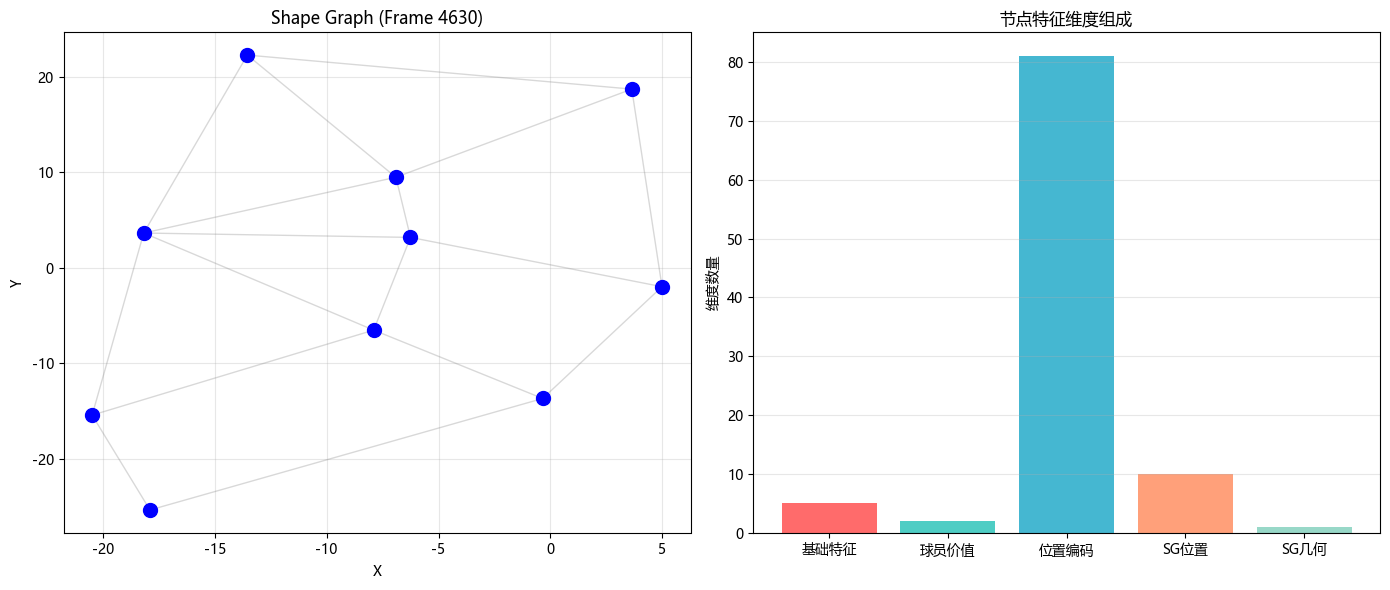

✅ 可视化已保存: ..\..\..\data\morph_test\bgnn_dataset\sample_graph_visualization.png


In [20]:
if len(dataset) > 0:
    print("=== 可视化示例数据 ===")
    
    sample_data = dataset[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 左图: 节点位置和边连接
    ax = axes[0]
    positions = sample_data.x[:, :2].numpy()  # 前两维是x, y
    
    # 绘制边
    edge_index = sample_data.edge_index.numpy()
    for i in range(0, edge_index.shape[1], 2):  # 跳过反向边
        u, v = edge_index[:, i]
        ax.plot([positions[u, 0], positions[v, 0]], 
               [positions[u, 1], positions[v, 1]], 
               'gray', alpha=0.3, linewidth=1)
    
    # 绘制节点
    ax.scatter(positions[:, 0], positions[:, 1], c='blue', s=100, zorder=5)
    
    # 标注节点序号
    for i, (x, y) in enumerate(positions):
        ax.text(x, y, str(i), fontsize=8, ha='center', va='center', color='white')
    
    ax.set_title(f'Shape Graph (Frame {sample_data.frame_id})')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(True, alpha=0.3)
    
    # 右图: 特征维度分布
    ax = axes[1]
    feature_groups = {
        '基础特征': 5,
        '球员价值': 2,
        '位置编码': 81,
        'SG位置': 10,
        'SG几何': 1,
    }
    
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
    ax.bar(feature_groups.keys(), feature_groups.values(), color=colors)
    ax.set_title('节点特征维度组成')
    ax.set_ylabel('维度数量')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'sample_graph_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ 可视化已保存: {OUTPUT_DIR / 'sample_graph_visualization.png'}")

## 总结

本notebook完成了以下工作:

1. ✅ 加载了所有预处理数据 (追踪数据、EFPI结果、Shape Graphs结果、Rosters数据、FIFA排名、博彩赔率)
2. ✅ 定义了特征编码函数 (Rosters位置矩阵、战术标签、几何特征)
3. ✅ 实现了Shape Graph几何特征计算 (质心、分散度、直径、最近距离、高级几何特征)
4. ✅ 构建了单帧图数据的函数
5. ✅ 批量构建了图数据集 (全量: 50,084帧，100%成功率)
6. ✅ 生成了数据集统计分析和可视化

## 已完成的关键改进

- ✅ **使用Rosters数据**: 替代FIFA球员数据，使用Gradient Sports提供的16种位置类型（positionGroupType）
- ✅ **5×5位置矩阵编码**: 将Rosters位置编码为25维向量，保留空间语义
- ✅ **完整EFPI阵型库**: 加载全部65种阵型模板作为输出类别
- ✅ **博彩赔率数据**: 在3.2.1中成功加载odds_2022WC.xlsx
- ✅ **全量数据处理**: 处理了全部50,084个有效帧
- ✅ **高级几何特征**: 新增5个Shape Graph高级几何特征（LpW、外凸包面积、紧密度、防线高度、最前球员位置）

## 下一步

### 1. 补充实际比赛情境数据
- **当前状态**: score_diff和time_elapsed使用placeholder值（0.0）
- **目标**: 从tracking_data或比赛事件数据中提取实际的比分差和比赛时间
- **优先级**: 高 - 这些是重要的全局特征

### 2. 完善博彩赔率提取
- **当前状态**: 博彩赔率已在3.2.1加载（odds_df），但在图构建中使用placeholder值
- **目标**: 从odds_df中正确提取决赛（阿根廷vs法国）的实际赔率
- **优先级**: 中 - 反映赛前实力对比

### 3. 补充到球距离特征
- **当前状态**: distance_to_ball使用placeholder值（0.0）
- **目标**: 从tracking_data中提取球的位置，计算每个球员到球的实际距离
- **优先级**: 中 - 重要的节点特征

### 4. 数据增强策略
- **目标**: 提高模型泛化能力，缓解类别不平衡问题
- **方法**:
  - 空间增强: 随机旋转、镜像翻转
  - 噪声注入: 位置坐标添加高斯噪声
  - 时间增强: 帧采样策略
- **优先级**: 中 - 在模型训练阶段实现

### 5. 处理类别不平衡
- **问题**: 65种阵型中有15种未在训练数据中出现
- **解决方案**:
  - 使用class_weight或Focal Loss
  - 评估时使用macro-F1而非accuracy
  - 考虑few-shot learning或zero-shot learning方法
- **优先级**: 高 - 影响模型公平性和泛化能力

### 6. 运行3.2.3 - B-GNN模型架构设计
- **目标**: 设计贝叶斯图神经网络模型
- **关键组件**:
  - 图卷积层设计（GCN/GAT/GraphSAGE）
  - 全局特征融合机制（如何整合22维全局特征）
  - 贝叶斯不确定性估计（MC Dropout或Variational Inference）
  - 损失函数设计（考虑类别不平衡）
  - 评估指标（accuracy、macro-F1、confusion matrix）
- **优先级**: 高 - 核心建模任务

## 关键设计决策

- ✅ **Rosters位置特征**: 使用5×5位置矩阵编码（25维），保留空间语义
- ✅ **Shape Graph特征**: 使用几何特征（vertical_levels, horizontal_positions, 质心, 分散度, 直径, 高级几何特征）
- ❌ **数据泄露防护**: 严格避免使用`formation_detailed`、`formation_code`等阵型标签作为输入特征
- ✅ **高级几何特征**: 从原始坐标(x, y)计算，而非缩放坐标(x_scaled, y_scaled)，保留原始长宽比信息
- ✅ **完整阵型库**: 使用全部65种EFPI阵型作为输出类别，确保与baseline公平比较